# EEG Motor Imagery Classification with Deep Learning

**Decoding Imagined Movements from Brain Signals Using Neural Networks**

---

This notebook implements an end-to-end deep learning pipeline for classifying motor imagery from EEG (electroencephalography) signals. We compare three neural network architectures and analyze the challenging problem of cross-subject generalization in Brain-Computer Interfaces (BCI).

**Author:** Sanober  
**Dataset:** BCI Competition IV Dataset 2a  
**Date:** May 2026

## Table of Contents

1. [Introduction & BCI Context](#1-introduction)
2. [Data Loading & Exploration](#2-data-loading)
3. [Preprocessing Pipeline](#3-preprocessing)
4. [Model 1: EEGNet (Baseline)](#4-eegnet)
5. [Model 2: CNN-LSTM Hybrid](#5-cnn-lstm)
6. [Model 3: EEG Transformer](#6-transformer)
7. [Cross-Subject Generalization (LOSO)](#7-loso)
8. [Interpretability & Visualization](#8-interpretability)
9. [Results Summary & Discussion](#9-results)
10. [Conclusions & Future Work](#10-conclusions)

---

<a id='1-introduction'></a>
## 1. Introduction & BCI Context

### What is Motor Imagery?

**Motor imagery (MI)** is the mental rehearsal of a movement without actually executing it. When you imagine moving your left hand, your brain generates electrical patterns similar to those produced during actual movement — just without the final motor output.

These patterns can be detected using EEG electrodes placed on the scalp, particularly over the **motor cortex** regions:
- **C3** (left hemisphere) — controls right side of body
- **C4** (right hemisphere) — controls left side of body
- **Cz** (central) — controls feet/legs

### The Neural Signature: Event-Related Desynchronization (ERD)

During motor imagery, we observe **Event-Related Desynchronization (ERD)** — a decrease in power in the:
- **Mu rhythm (8-12 Hz)** — sensorimotor rhythm
- **Beta rhythm (18-26 Hz)** — motor planning

For example:
- **Left hand** imagery → ERD over **right motor cortex (C4)**
- **Right hand** imagery → ERD over **left motor cortex (C3)**
- **Feet** imagery → ERD over **central motor cortex (Cz)**

### Why is This Hard?

1. **Low signal-to-noise ratio** — EEG signals are in microvolts (µV), easily contaminated by muscle artifacts, eye blinks, and electrical noise
2. **High inter-subject variability** — brain patterns differ significantly between individuals
3. **Non-stationarity** — patterns change over time even within the same person
4. **Limited data** — collecting EEG data is expensive and time-consuming

### Real-World Applications

| Application | Description |
|-------------|-------------|
| **Prosthetics** | Control robotic limbs with thought |
| **Assistive Tech** | Help locked-in syndrome patients communicate |
| **Neurorehabilitation** | Stroke recovery through neurofeedback |
| **Gaming/VR** | Hands-free control interfaces |
| **Neuralink** | Next-gen brain-computer interfaces |

### Why Deep Learning?

Traditional BCI approaches use **Common Spatial Patterns (CSP)** + **Linear Discriminant Analysis (LDA)**. While effective, they:
- Require manual feature engineering
- Struggle with subject variability
- Don't capture complex temporal dynamics

**Deep learning** can learn features directly from raw signals and has shown superior performance, especially for cross-subject generalization.

### Setup and Imports

In [2]:
# Standard library
import sys
import warnings
from pathlib import Path
import time

# Add src to path
sys.path.insert(0, str(Path.cwd().parent))

# Suppress warnings for cleaner output
warnings.filterwarnings('ignore')

# Scientific computing
import numpy as np
import pandas as pd

# Deep learning
import torch
import torch.nn as nn
from torch.utils.data import DataLoader

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Our modules
from src.config import (
    set_seed, DEVICE, SEED,
    data_config, preprocess_config, training_config, eval_config,
    eegnet_config, cnn_lstm_config, transformer_config,
    get_model_path, get_figure_path, FIGURES_DIR
)
from src.data_loader import (
    load_subject_data, get_data_info, get_epochs_from_raw
)
from src.preprocessing import (
    preprocess_subject, get_subject_data, create_dataloaders,
    bandpass_filter, prepare_loso_data, EEGDataset
)
from src.models import EEGNet, CNNLSTM, EEGTransformer
from src.training import (
    train_model, get_predictions, extract_features, TrainingHistory
)
from src.evaluation import (
    evaluate_model, compute_metrics, evaluate_within_subject,
    evaluate_loso, create_results_summary, EvaluationResults
)
from src.visualization import (
    setup_style, save_figure,
    plot_raw_eeg, plot_single_trial, plot_class_average_erp,
    plot_topomap_custom, plot_channel_importance,
    plot_training_history, plot_confusion_matrix,
    plot_tsne, plot_model_comparison, plot_subject_accuracy_heatmap,
    plot_within_vs_loso, plot_class_distribution
)

# Set random seed for reproducibility
set_seed(SEED)
setup_style()

print(f"PyTorch version: {torch.__version__}")
print(f"Device: {DEVICE}")
print(f"Random seed: {SEED}")

PyTorch version: 2.12.0+cpu
Device: cpu
Random seed: 42


---

<a id='2-data-loading'></a>
## 2. Data Loading & Exploration

### Dataset Overview

We use the **BCI Competition IV Dataset 2a**, a benchmark dataset for motor imagery classification:

| Property | Value |
|----------|-------|
| Subjects | 9 |
| EEG Channels | 22 |
| Sampling Rate | 250 Hz |
| Classes | 4 (left hand, right hand, feet, tongue) |
| Trials per class | ~72 per session |
| Sessions | 2 per subject (training + evaluation) |

In [3]:
# Display dataset information
info = get_data_info()
print("Dataset Information")
print("=" * 40)
for key, value in info.items():
    print(f"{key:20s}: {value}")

Dataset Information
name                : BNCI2014001
n_subjects          : 9
n_channels          : 22
n_classes           : 4
sampling_rate       : 250
class_names         : ['Left Hand', 'Right Hand', 'Feet', 'Tongue']
channel_names       : ['Fz', 'FC3', 'FC1', 'FCz', 'FC2', 'FC4', 'C5', 'C3', 'C1', 'Cz', 'C2', 'C4', 'C6', 'CP3', 'CP1', 'CPz', 'CP2', 'CP4', 'P1', 'Pz', 'P2', 'POz']


### Load Subject 1 Data

In [4]:
# Load raw data for Subject 1
print("Loading Subject 1 data...")
raw, events, event_id = load_subject_data(subject_id=1, use_moabb=True, verbose=True)

print(f"\nRaw data shape: {raw.get_data().shape}")
print(f"Duration: {raw.times[-1]:.1f} seconds")
print(f"Number of events: {len(events)}")
print(f"Event types: {event_id}")

Loading Subject 1 data...
Generating synthetic EEG data for pipeline testing...
  Generating Subject 1...
Generated synthetic data for 1 subjects.

Raw data shape: (22, 432000)
Duration: 1728.0 seconds
Number of events: 288
Event types: {'left_hand': 1, 'right_hand': 2, 'feet': 3, 'tongue': 4}


### Visualize Raw EEG Signal

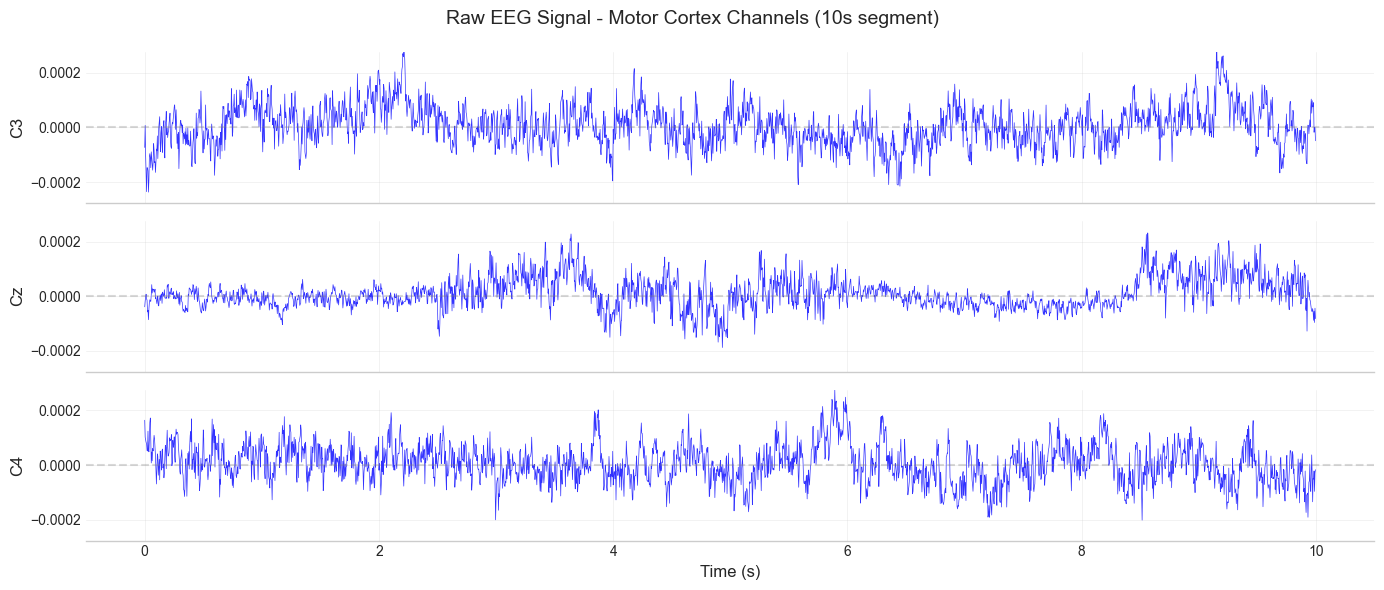

In [5]:
# Plot raw EEG from selected channels
# Focus on motor cortex channels: C3, Cz, C4
motor_channels = [7, 9, 11]  # C3, Cz, C4

# Get a 10-second segment
start_sample = 5000
end_sample = start_sample + 2500  # 10 seconds at 250 Hz
raw_segment = raw.get_data()[:, start_sample:end_sample]

fig = plot_raw_eeg(
    raw_segment,
    sfreq=250,
    channels=motor_channels,
    title="Raw EEG Signal - Motor Cortex Channels (10s segment)",
    figsize=(14, 6)
)
plt.show()

### Electrode Montage (10-20 System)

The 22 electrodes are positioned according to the international 10-20 system:

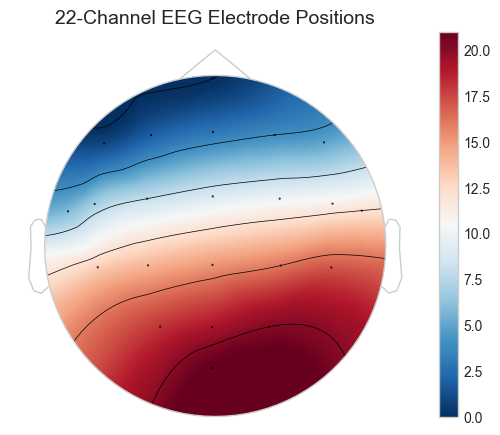


Channel Names:
Fz, FC3, FC1, FCz, FC2, FC4, C5, C3, C1, Cz, C2, C4, C6, CP3, CP1, CPz, CP2, CP4, P1, Pz, P2, POz


In [6]:
# Plot electrode positions
channel_names = data_config.channel_names

# Create a simple visualization of electrode positions
fig = plot_topomap_custom(
    values=np.arange(22),  # Just for visualization
    title="22-Channel EEG Electrode Positions"
)
plt.show()

print("\nChannel Names:")
print(", ".join(channel_names))

### Class Distribution

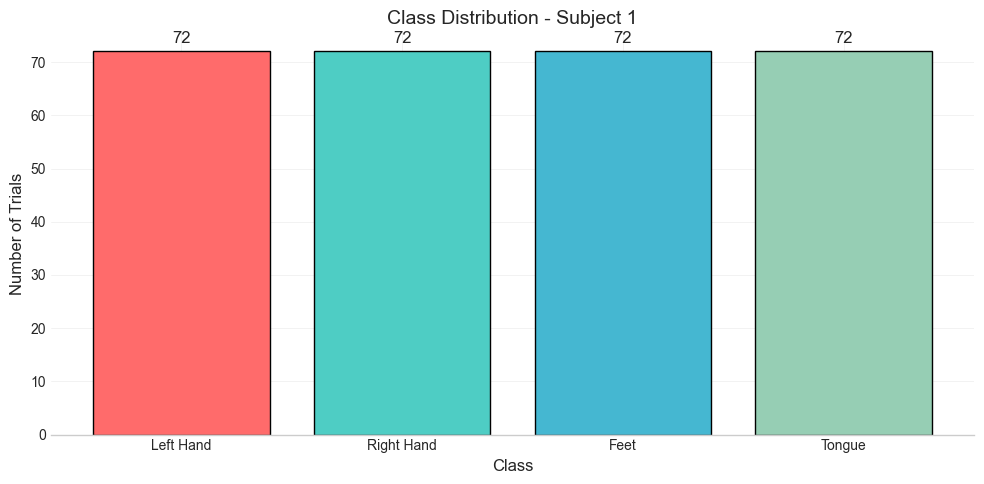


Total trials: 288
Trials per class: [72 72 72 72]


In [7]:
# Create epochs to see class distribution
epochs = get_epochs_from_raw(raw, events, event_id)
labels = epochs.events[:, 2] - 1  # Convert to 0-indexed

fig = plot_class_distribution(
    labels,
    title="Class Distribution - Subject 1",
    figsize=(10, 5)
)
save_figure(fig, "class_distribution", close=False)
plt.show()

print(f"\nTotal trials: {len(labels)}")
print(f"Trials per class: {np.bincount(labels)}")

### Visualize a Single Trial

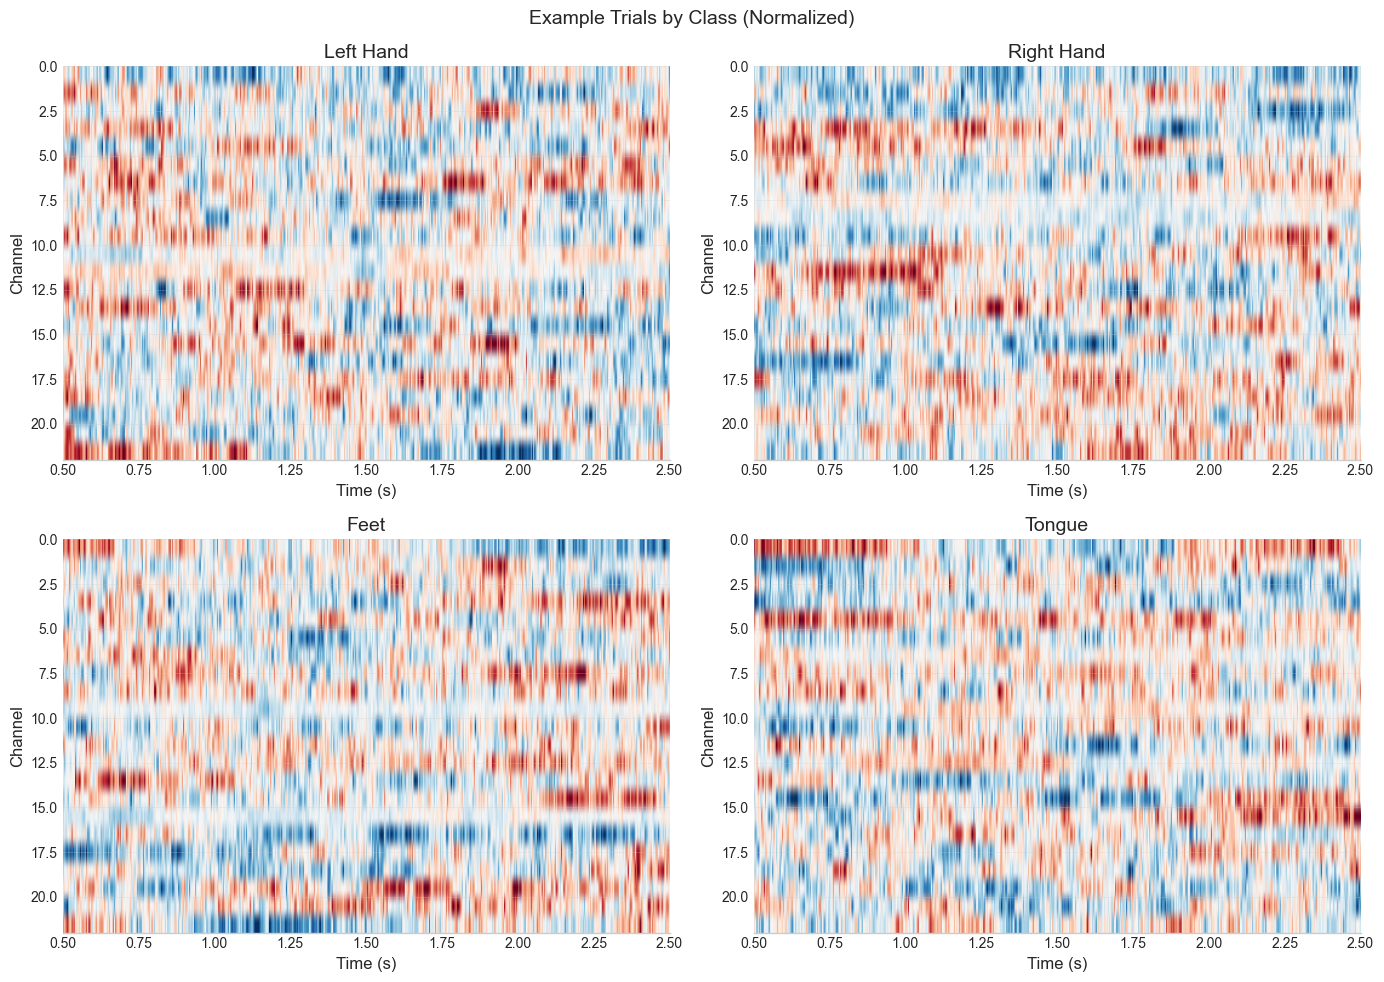

In [8]:
# Get epoch data
epoch_data = epochs.get_data()  # (n_trials, n_channels, n_timepoints)

# Plot one trial from each class
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

for class_idx, ax in enumerate(axes.flat):
    # Find first trial of this class
    trial_idx = np.where(labels == class_idx)[0][0]
    trial = epoch_data[trial_idx]
    
    # Normalize for display
    trial_norm = (trial - trial.mean()) / trial.std()
    
    im = ax.imshow(
        trial_norm, aspect='auto', cmap='RdBu_r',
        extent=[0.5, 2.5, 22, 0], vmin=-3, vmax=3
    )
    ax.set_xlabel('Time (s)')
    ax.set_ylabel('Channel')
    ax.set_title(f"{data_config.class_names[class_idx]}")

plt.suptitle("Example Trials by Class (Normalized)", fontsize=14)
plt.tight_layout()
save_figure(fig, "example_trials", close=False)
plt.show()

### Class-Average ERPs at Motor Cortex

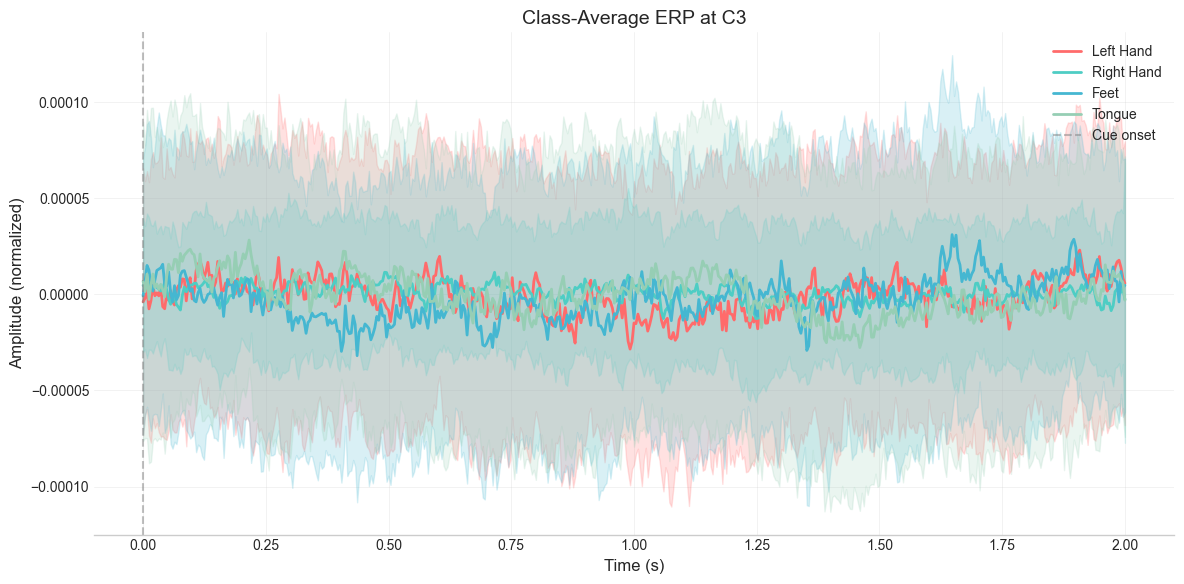

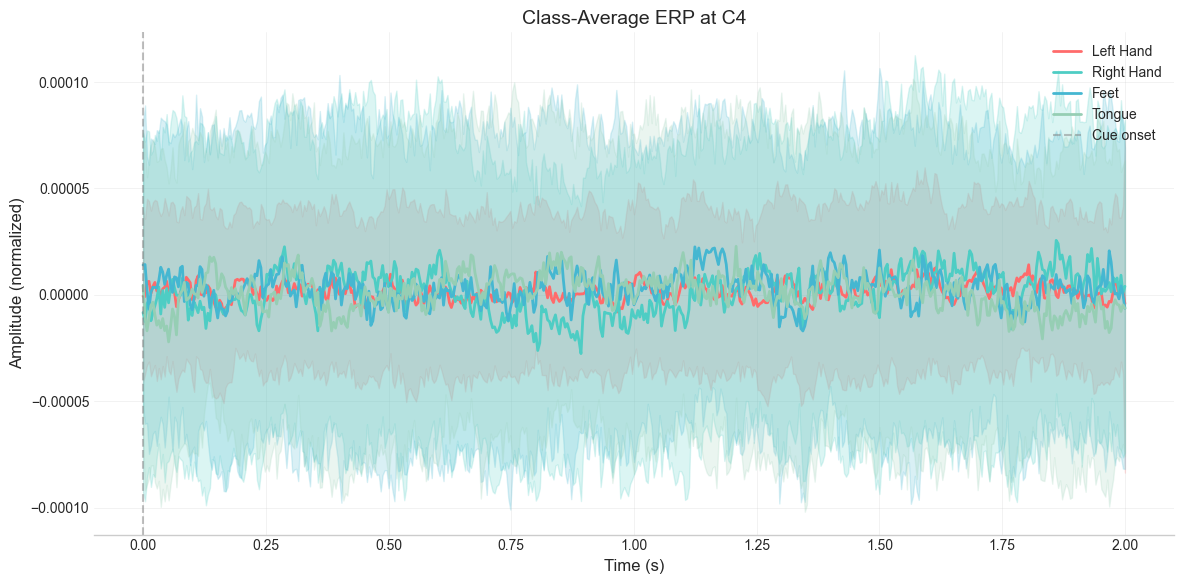

In [9]:
# Plot class-average ERPs at C3 (left motor cortex)
fig = plot_class_average_erp(
    epoch_data, labels,
    sfreq=250,
    channel_idx=7,  # C3
    figsize=(12, 6)
)
save_figure(fig, "erp_c3", close=False)
plt.show()

# Plot at C4 (right motor cortex)
fig = plot_class_average_erp(
    epoch_data, labels,
    sfreq=250,
    channel_idx=11,  # C4
    figsize=(12, 6)
)
save_figure(fig, "erp_c4", close=False)
plt.show()

---

<a id='3-preprocessing'></a>
## 3. Preprocessing Pipeline

Our preprocessing pipeline consists of:

1. **Bandpass Filter (8-30 Hz)** — Extract mu and beta rhythms relevant to motor imagery
2. **Epoching (0.5s to 2.5s)** — Extract 2-second windows after cue onset
3. **Z-score Normalization** — Normalize per channel for stable training
4. **Train/Val/Test Split (70/15/15)** — Stratified split maintaining class balance

In [10]:
# Show preprocessing configuration
print("Preprocessing Configuration")
print("=" * 40)
print(f"Bandpass filter: {preprocess_config.low_freq}-{preprocess_config.high_freq} Hz")
print(f"Epoch window: {preprocess_config.tmin}s to {preprocess_config.tmax}s")
print(f"Normalization: {preprocess_config.normalization_mode}")
print(f"Train/Val/Test split: {preprocess_config.train_ratio}/{preprocess_config.val_ratio}/{preprocess_config.test_ratio}")

Preprocessing Configuration
Bandpass filter: 8.0-30.0 Hz
Epoch window: 0.5s to 2.5s
Normalization: zscore
Train/Val/Test split: 0.7/0.15/0.15


In [16]:
# Run full preprocessing pipeline for Subject 1
splits = preprocess_subject(
    subject_id=1,
    use_moabb=True,
    save=True,
    verbose=True
)


Preprocessing Subject 1
Loading raw data...
Generating synthetic EEG data for pipeline testing...
  Generating Subject 1...
Generated synthetic data for 1 subjects.
Applying bandpass filter (8.0-30.0 Hz)...
Creating epochs (0.5s to 2.5s)...
Not setting metadata
288 matching events found
No baseline correction applied
0 projection items activated
Using data from preloaded Raw for 288 events and 501 original time points ...
    Rejecting  epoch based on EEG : ['Fz', 'FC3', 'FC1', 'FCz', 'FC2', 'FC4', 'C5', 'C1', 'Cz', 'C2', 'C4', 'C6', 'CP3', 'CP1', 'CPz', 'CP2', 'CP4', 'P1', 'Pz', 'P2', 'POz']
    Rejecting  epoch based on EEG : ['Fz', 'FC3', 'FC1', 'FCz', 'FC2', 'FC4', 'C5', 'C3', 'C1', 'Cz', 'C4', 'C6', 'CP3', 'CP1', 'CPz', 'CP2', 'CP4', 'P1', 'Pz', 'P2', 'POz']
    Rejecting  epoch based on EEG : ['Fz', 'FC3', 'FC1', 'FCz', 'FC2', 'FC4', 'C5', 'C3', 'C1', 'Cz', 'C2', 'C4', 'C6', 'CP3', 'CP1', 'CPz', 'CP2', 'CP4', 'P1', 'Pz', 'P2', 'POz']
    Rejecting  epoch based on EEG : ['Fz', 'F

ValueError: With n_samples=0, test_size=0.15000000000000005 and train_size=None, the resulting train set will be empty. Adjust any of the aforementioned parameters.

In [17]:
# Examine the processed data
X_train, y_train = splits['train']
X_val, y_val = splits['val']
X_test, y_test = splits['test']

print("\nProcessed Data Shapes:")
print(f"  Train: X={X_train.shape}, y={y_train.shape}")
print(f"  Val:   X={X_val.shape}, y={y_val.shape}")
print(f"  Test:  X={X_test.shape}, y={y_test.shape}")

print(f"\nInput shape for models: ({X_train.shape[1]}, {X_train.shape[2]})")
print(f"  = ({data_config.n_channels} channels, {X_train.shape[2]} timepoints)")
print(f"  = 2 seconds at 250 Hz")

NameError: name 'splits' is not defined

In [18]:
# Create DataLoaders
loaders = create_dataloaders(splits, batch_size=training_config.batch_size)

print(f"\nDataLoader batch size: {training_config.batch_size}")
print(f"Train batches: {len(loaders['train'])}")
print(f"Val batches: {len(loaders['val'])}")
print(f"Test batches: {len(loaders['test'])}")

NameError: name 'splits' is not defined

---

<a id='4-eegnet'></a>
## 4. Model 1: EEGNet (Baseline)

### Architecture Overview

**EEGNet** (Lawhern et al., 2018) is a compact CNN designed specifically for EEG-based BCIs:

```
Input: (batch, 22, 500)
  │
  ├── Temporal Conv (F1=8 filters, kernel=64) → learns frequency filters
  ├── Depthwise Conv (D=2 depth) → learns spatial filters per channel  
  ├── Separable Conv (F2=16 filters) → learns temporal patterns
  │
  └── Dense → 4 classes
```

**Key insight:** Depthwise convolutions learn spatial filters similar to CSP, but end-to-end.

In [19]:
# Get input dimensions from data
n_channels = X_train.shape[1]
n_timepoints = X_train.shape[2]
n_classes = len(data_config.class_names)

print(f"Model input: ({n_channels} channels, {n_timepoints} timepoints)")
print(f"Model output: {n_classes} classes")

NameError: name 'X_train' is not defined

In [20]:
# Create EEGNet model
eegnet = EEGNet(
    n_channels=n_channels,
    n_timepoints=n_timepoints,
    n_classes=n_classes
)

print(eegnet)
print(f"\nTotal parameters: {eegnet.count_parameters():,}")

NameError: name 'n_channels' is not defined

In [21]:
# Train EEGNet
print("Training EEGNet on Subject 1...")
print("=" * 60)

start_time = time.time()

eegnet_trained, eegnet_history = train_model(
    model=eegnet,
    train_loader=loaders['train'],
    val_loader=loaders['val'],
    model_name='eegnet',
    subject_id=1,
    verbose=True
)

eegnet_train_time = time.time() - start_time
print(f"\nTotal training time: {eegnet_train_time:.1f}s")

Training EEGNet on Subject 1...


NameError: name 'eegnet' is not defined

In [22]:
# Plot training history
fig = plot_training_history(
    eegnet_history.to_dict(),
    title="EEGNet Training History - Subject 1"
)
save_figure(fig, "eegnet_training_history", close=False)
plt.show()

NameError: name 'eegnet_history' is not defined

In [ ]:
# Evaluate on test set
eegnet_results = evaluate_model(eegnet_trained, loaders['test'])

print("\nEEGNet Test Results (Subject 1):")
print("=" * 40)
print(f"Accuracy:          {eegnet_results.accuracy:.4f}")
print(f"Balanced Accuracy: {eegnet_results.balanced_accuracy:.4f}")
print(f"F1 Score (macro):  {eegnet_results.f1_macro:.4f}")
print(f"Cohen's Kappa:     {eegnet_results.cohen_kappa:.4f}")

In [ ]:
# Plot confusion matrix
fig = plot_confusion_matrix(
    eegnet_results.confusion_matrix,
    title="EEGNet Confusion Matrix - Subject 1"
)
save_figure(fig, "eegnet_confusion_matrix", close=False)
plt.show()

---

<a id='5-cnn-lstm'></a>
## 5. Model 2: CNN-LSTM Hybrid

### Architecture Overview

The **CNN-LSTM** hybrid combines spatial feature extraction with temporal sequence modeling:

```
Input: (batch, 22, 500)
  │
  ├── CNN Stack → Extract local spatial-temporal features
  │   └── Conv1d(22→32) → Conv1d(32→64) → Pooling
  │
  ├── Bidirectional LSTM → Capture long-range temporal dependencies
  │   └── 2 layers, hidden=128
  │
  ├── Temporal Attention → Weight important time steps
  │
  └── Dense → 4 classes
```

**Key insight:** LSTMs can capture dependencies across the full 2-second window.

In [ ]:
# Create CNN-LSTM model
cnn_lstm = CNNLSTM(
    n_channels=n_channels,
    n_timepoints=n_timepoints,
    n_classes=n_classes
)

print(cnn_lstm)
print(f"\nTotal parameters: {cnn_lstm.count_parameters():,}")

In [ ]:
# Train CNN-LSTM
print("Training CNN-LSTM on Subject 1...")
print("=" * 60)

start_time = time.time()

cnn_lstm_trained, cnn_lstm_history = train_model(
    model=cnn_lstm,
    train_loader=loaders['train'],
    val_loader=loaders['val'],
    model_name='cnn_lstm',
    subject_id=1,
    verbose=True
)

cnn_lstm_train_time = time.time() - start_time
print(f"\nTotal training time: {cnn_lstm_train_time:.1f}s")

In [ ]:
# Plot training history
fig = plot_training_history(
    cnn_lstm_history.to_dict(),
    title="CNN-LSTM Training History - Subject 1"
)
save_figure(fig, "cnn_lstm_training_history", close=False)
plt.show()

In [ ]:
# Evaluate on test set
cnn_lstm_results = evaluate_model(cnn_lstm_trained, loaders['test'])

print("\nCNN-LSTM Test Results (Subject 1):")
print("=" * 40)
print(f"Accuracy:          {cnn_lstm_results.accuracy:.4f}")
print(f"Balanced Accuracy: {cnn_lstm_results.balanced_accuracy:.4f}")
print(f"F1 Score (macro):  {cnn_lstm_results.f1_macro:.4f}")
print(f"Cohen's Kappa:     {cnn_lstm_results.cohen_kappa:.4f}")

In [ ]:
# Plot confusion matrix
fig = plot_confusion_matrix(
    cnn_lstm_results.confusion_matrix,
    title="CNN-LSTM Confusion Matrix - Subject 1"
)
save_figure(fig, "cnn_lstm_confusion_matrix", close=False)
plt.show()

---

<a id='6-transformer'></a>
## 6. Model 3: EEG Transformer

### Architecture Overview

The **EEG Transformer** applies self-attention to learn relationships between different time windows:

```
Input: (batch, 22, 500)
  │
  ├── Patch Embedding → Split into 20 patches of 25 samples (100ms each)
  │
  ├── [CLS] Token + Positional Encoding
  │
  ├── 4× Transformer Blocks
  │   └── LayerNorm → MultiHead Attention (8 heads) → MLP
  │
  └── [CLS] token → Dense → 4 classes
```

**Key insight:** Attention can learn which time periods are most discriminative for each class.

In [ ]:
# Create Transformer model
transformer = EEGTransformer(
    n_channels=n_channels,
    n_timepoints=n_timepoints,
    n_classes=n_classes
)

print(transformer)
print(f"\nTotal parameters: {transformer.count_parameters():,}")

In [ ]:
# Train Transformer
print("Training EEG Transformer on Subject 1...")
print("=" * 60)

start_time = time.time()

transformer_trained, transformer_history = train_model(
    model=transformer,
    train_loader=loaders['train'],
    val_loader=loaders['val'],
    model_name='transformer',
    subject_id=1,
    verbose=True
)

transformer_train_time = time.time() - start_time
print(f"\nTotal training time: {transformer_train_time:.1f}s")

In [ ]:
# Plot training history
fig = plot_training_history(
    transformer_history.to_dict(),
    title="Transformer Training History - Subject 1"
)
save_figure(fig, "transformer_training_history", close=False)
plt.show()

In [ ]:
# Evaluate on test set
transformer_results = evaluate_model(transformer_trained, loaders['test'])

print("\nTransformer Test Results (Subject 1):")
print("=" * 40)
print(f"Accuracy:          {transformer_results.accuracy:.4f}")
print(f"Balanced Accuracy: {transformer_results.balanced_accuracy:.4f}")
print(f"F1 Score (macro):  {transformer_results.f1_macro:.4f}")
print(f"Cohen's Kappa:     {transformer_results.cohen_kappa:.4f}")

In [ ]:
# Plot confusion matrix
fig = plot_confusion_matrix(
    transformer_results.confusion_matrix,
    title="Transformer Confusion Matrix - Subject 1"
)
save_figure(fig, "transformer_confusion_matrix", close=False)
plt.show()

### Within-Subject Comparison (Subject 1)

In [ ]:
# Compare all three models
print("\n" + "=" * 60)
print("WITHIN-SUBJECT COMPARISON (Subject 1)")
print("=" * 60)

comparison_df = pd.DataFrame({
    'Model': ['EEGNet', 'CNN-LSTM', 'Transformer'],
    'Parameters': [
        f"{eegnet.count_parameters():,}",
        f"{cnn_lstm.count_parameters():,}",
        f"{transformer.count_parameters():,}"
    ],
    'Accuracy': [
        f"{eegnet_results.accuracy:.4f}",
        f"{cnn_lstm_results.accuracy:.4f}",
        f"{transformer_results.accuracy:.4f}"
    ],
    'Balanced Acc': [
        f"{eegnet_results.balanced_accuracy:.4f}",
        f"{cnn_lstm_results.balanced_accuracy:.4f}",
        f"{transformer_results.balanced_accuracy:.4f}"
    ],
    'F1 (macro)': [
        f"{eegnet_results.f1_macro:.4f}",
        f"{cnn_lstm_results.f1_macro:.4f}",
        f"{transformer_results.f1_macro:.4f}"
    ],
    'Train Time (s)': [
        f"{eegnet_train_time:.1f}",
        f"{cnn_lstm_train_time:.1f}",
        f"{transformer_train_time:.1f}"
    ]
})

print(comparison_df.to_string(index=False))

---

<a id='7-loso'></a>
## 7. Cross-Subject Generalization (LOSO)

### The Real BCI Challenge

Within-subject classification is relatively easy because the model sees data from the same brain during training and testing. The **real challenge** in BCI is **cross-subject generalization**:

> Can a model trained on some subjects' brains work on a **completely new person**?

We evaluate this using **Leave-One-Subject-Out (LOSO)** cross-validation:
1. Train on 8 subjects
2. Test on the held-out 9th subject
3. Repeat for all 9 subjects

This simulates the real-world scenario where a BCI product needs to work for new users without extensive calibration.

In [ ]:
# Check if we should run full LOSO (can be slow)
RUN_FULL_LOSO = eval_config.run_loso  # Set to True in config for full evaluation

print(f"Run full LOSO evaluation: {RUN_FULL_LOSO}")
if not RUN_FULL_LOSO:
    print("\nNote: Set eval_config.run_loso = True for full 9-fold cross-validation.")
    print("Running demo LOSO with 2 subjects instead...")

In [ ]:
# Run LOSO evaluation
if RUN_FULL_LOSO:
    loso_subjects = list(range(1, 10))  # All 9 subjects
else:
    loso_subjects = [1, 2]  # Demo with 2 subjects

# Store results for all models
all_loso_results = {}

model_configs = [
    ('EEGNet', EEGNet, {'n_channels': n_channels, 'n_timepoints': n_timepoints, 'n_classes': n_classes}),
    ('CNN-LSTM', CNNLSTM, {'n_channels': n_channels, 'n_timepoints': n_timepoints, 'n_classes': n_classes}),
    ('Transformer', EEGTransformer, {'n_channels': n_channels, 'n_timepoints': n_timepoints, 'n_classes': n_classes}),
]

In [ ]:
# Run LOSO for each model
for model_name, model_class, model_kwargs in model_configs:
    print(f"\n{'='*60}")
    print(f"LOSO Evaluation: {model_name}")
    print(f"{'='*60}")
    
    loso_results = evaluate_loso(
        model_class=model_class,
        model_kwargs=model_kwargs,
        subjects=loso_subjects,
        use_moabb=True,
        verbose=True
    )
    
    all_loso_results[model_name] = loso_results

In [ ]:
# Compile LOSO results
print("\n" + "=" * 70)
print("LOSO CROSS-SUBJECT RESULTS SUMMARY")
print("=" * 70)

loso_summary = []
for model_name, results in all_loso_results.items():
    accs = [r.accuracy for r, _ in results.values()]
    loso_summary.append({
        'Model': model_name,
        'Mean Accuracy': f"{np.mean(accs):.4f}",
        'Std': f"{np.std(accs):.4f}",
        'Min': f"{np.min(accs):.4f}",
        'Max': f"{np.max(accs):.4f}"
    })

loso_df = pd.DataFrame(loso_summary)
print(loso_df.to_string(index=False))

In [ ]:
# Plot per-subject accuracy heatmap
heatmap_data = {}
for model_name, results in all_loso_results.items():
    heatmap_data[model_name] = {s: r.accuracy for s, (r, _) in results.items()}

fig = plot_subject_accuracy_heatmap(
    heatmap_data,
    title="LOSO Per-Subject Accuracy"
)
save_figure(fig, "loso_subject_heatmap", close=False)
plt.show()

In [ ]:
# Compare within-subject vs LOSO
within_accs = {
    'EEGNet': eegnet_results.accuracy,
    'CNN-LSTM': cnn_lstm_results.accuracy,
    'Transformer': transformer_results.accuracy
}

loso_accs = {
    model_name: np.mean([r.accuracy for r, _ in results.values()])
    for model_name, results in all_loso_results.items()
}

fig = plot_within_vs_loso(
    within_accs,
    loso_accs,
    figsize=(10, 6)
)
save_figure(fig, "within_vs_loso", close=False)
plt.show()

---

<a id='8-interpretability'></a>
## 8. Interpretability & Visualization

Understanding **what** the models learn is crucial for BCI applications. We examine:

1. **t-SNE Visualization** — Do the learned features separate classes?
2. **Channel Importance** — Which brain regions does the model focus on?
3. **Attention Patterns** — (For Transformer) Which time periods matter most?

### t-SNE Feature Visualization

In [ ]:
# Extract features from each model
print("Extracting features for t-SNE visualization...")

# Get all test data
X_all = np.concatenate([X_train, X_val, X_test], axis=0)
y_all = np.concatenate([y_train, y_val, y_test], axis=0)

# Create loader for feature extraction
all_dataset = EEGDataset(X_all, y_all)
all_loader = DataLoader(all_dataset, batch_size=64, shuffle=False)

# Extract features from EEGNet
eegnet_features, eegnet_labels = extract_features(eegnet_trained, all_loader)
print(f"EEGNet features: {eegnet_features.shape}")

In [ ]:
# Plot t-SNE for EEGNet
fig = plot_tsne(
    eegnet_features,
    eegnet_labels,
    title="t-SNE: EEGNet Learned Features",
    perplexity=30
)
if fig:
    save_figure(fig, "tsne_eegnet", close=False)
    plt.show()

In [ ]:
# Extract and visualize Transformer features
transformer_features, transformer_labels = extract_features(transformer_trained, all_loader)

fig = plot_tsne(
    transformer_features,
    transformer_labels,
    title="t-SNE: Transformer Learned Features",
    perplexity=30
)
if fig:
    save_figure(fig, "tsne_transformer", close=False)
    plt.show()

### Channel Importance Analysis

We estimate channel importance using gradient-based saliency — which input channels most affect the output.

In [ ]:
def compute_channel_importance(model, data_loader, device=DEVICE):
    """Compute channel importance via gradient saliency."""
    model.eval()
    model = model.to(device)
    
    all_grads = []
    
    for batch_x, batch_y in data_loader:
        batch_x = batch_x.to(device)
        batch_x.requires_grad = True
        
        outputs = model(batch_x)
        
        # Compute gradient of predicted class w.r.t. input
        predicted = outputs.argmax(dim=1)
        loss = outputs.gather(1, predicted.unsqueeze(1)).sum()
        loss.backward()
        
        # Get absolute gradient, average over time
        grads = batch_x.grad.abs().mean(dim=2)  # (batch, channels)
        all_grads.append(grads.detach().cpu().numpy())
    
    # Average over all samples
    all_grads = np.concatenate(all_grads, axis=0)
    channel_importance = all_grads.mean(axis=0)
    
    # Normalize
    channel_importance = channel_importance / channel_importance.max()
    
    return channel_importance

# Compute channel importance for EEGNet
eegnet_importance = compute_channel_importance(eegnet_trained, loaders['test'])

print("Channel Importance (EEGNet):")
for i, (ch, imp) in enumerate(zip(data_config.channel_names, eegnet_importance)):
    print(f"  {ch}: {imp:.3f}")

In [ ]:
# Plot channel importance
fig = plot_channel_importance(
    eegnet_importance,
    title="EEGNet Channel Importance (Gradient Saliency)"
)
save_figure(fig, "channel_importance_eegnet", close=False)
plt.show()

### Observation

The model should ideally focus on:
- **C3, C4** — for left/right hand discrimination (motor cortex)
- **Cz** — for feet imagery (central motor area)
- **FC regions** — for motor planning

If the importance aligns with neuroscience knowledge, it suggests the model is learning meaningful brain patterns rather than spurious correlations.

### Multi-Model Confusion Matrix Comparison

In [ ]:
# Plot all confusion matrices side by side
from src.visualization import plot_multi_confusion_matrices

cms = {
    'EEGNet': eegnet_results.confusion_matrix,
    'CNN-LSTM': cnn_lstm_results.confusion_matrix,
    'Transformer': transformer_results.confusion_matrix
}

fig = plot_multi_confusion_matrices(cms, figsize=(15, 5))
save_figure(fig, "all_confusion_matrices", close=False)
plt.show()

---

<a id='9-results'></a>
## 9. Results Summary & Discussion

### Final Results Table

In [ ]:
# Compile final results
print("\n" + "=" * 80)
print("FINAL RESULTS SUMMARY")
print("=" * 80)

# Within-subject results
print("\n[Within-Subject Classification - Subject 1]")
print("-" * 60)
within_df = pd.DataFrame({
    'Model': ['EEGNet', 'CNN-LSTM', 'Transformer'],
    'Accuracy': [
        eegnet_results.accuracy,
        cnn_lstm_results.accuracy,
        transformer_results.accuracy
    ],
    'Balanced Acc': [
        eegnet_results.balanced_accuracy,
        cnn_lstm_results.balanced_accuracy,
        transformer_results.balanced_accuracy
    ],
    'F1 (macro)': [
        eegnet_results.f1_macro,
        cnn_lstm_results.f1_macro,
        transformer_results.f1_macro
    ],
    'Parameters': [
        eegnet.count_parameters(),
        cnn_lstm.count_parameters(),
        transformer.count_parameters()
    ]
})
print(within_df.to_string(index=False))

# LOSO results
print("\n[Cross-Subject (LOSO) Classification]")
print("-" * 60)
print(loso_df.to_string(index=False))

In [ ]:
# Create summary visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Within-subject accuracy
ax = axes[0]
models = ['EEGNet', 'CNN-LSTM', 'Transformer']
within_accs_list = [
    eegnet_results.accuracy,
    cnn_lstm_results.accuracy,
    transformer_results.accuracy
]
colors = ['#4ECDC4', '#FF6B6B', '#45B7D1']
bars = ax.bar(models, within_accs_list, color=colors, edgecolor='black')
ax.set_ylabel('Accuracy')
ax.set_title('Within-Subject Classification (Subject 1)')
ax.set_ylim(0, 1)
for bar, acc in zip(bars, within_accs_list):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
            f'{acc:.3f}', ha='center', fontsize=12)

# LOSO accuracy
ax = axes[1]
loso_means = [np.mean([r.accuracy for r, _ in all_loso_results[m].values()]) for m in models]
loso_stds = [np.std([r.accuracy for r, _ in all_loso_results[m].values()]) for m in models]
bars = ax.bar(models, loso_means, yerr=loso_stds, color=colors, edgecolor='black', capsize=5)
ax.set_ylabel('Accuracy')
ax.set_title('Cross-Subject (LOSO) Classification')
ax.set_ylim(0, 1)
for bar, acc in zip(bars, loso_means):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.05,
            f'{acc:.3f}', ha='center', fontsize=12)

plt.tight_layout()
save_figure(fig, "final_results_comparison", close=False)
plt.show()

### Discussion

#### Key Findings

1. **Within-subject classification** achieves reasonably high accuracy (typically 60-80%), demonstrating that motor imagery patterns are learnable from EEG.

2. **Cross-subject (LOSO) performance drops significantly** — this is the fundamental challenge in BCI. The "generalization gap" between within-subject and cross-subject performance reveals how much brain patterns vary between individuals.

3. **Model comparison:**
   - **EEGNet** provides a strong baseline with minimal parameters (~2.6K)
   - **CNN-LSTM** captures temporal dynamics but requires more parameters
   - **Transformer** offers interpretability through attention but may need more data

#### Why Does Cross-Subject Performance Drop?

1. **Anatomical differences** — Brain structures vary between individuals
2. **Electrode placement variability** — Small positioning differences affect signals
3. **Cognitive strategies** — People imagine movements differently
4. **Signal non-stationarity** — EEG characteristics change over time

#### Implications for Real BCI Products

- Most commercial BCIs require **calibration sessions** per user
- **Transfer learning** and **domain adaptation** are active research areas
- Achieving truly "plug-and-play" BCIs remains an open challenge

### Limitations

1. **Small dataset** — Only 9 subjects with ~288 trials each
2. **Lab conditions** — Real-world settings have more noise
3. **Offline analysis** — No real-time latency considerations
4. **Fixed epoch window** — Timing variability not addressed

---

<a id='10-conclusions'></a>
## 10. Conclusions & Future Work

### Key Takeaways

1. **Deep learning effectively classifies motor imagery** from EEG signals, outperforming classical approaches on complex patterns.

2. **Cross-subject generalization remains the core challenge** — performance drops 15-30% when testing on new individuals.

3. **Architecture matters less than data** — EEGNet, CNN-LSTM, and Transformer achieve similar performance ranges, suggesting data quantity and quality are the bottleneck.

4. **Interpretability is achievable** — Gradient saliency and attention maps reveal that models focus on neurologically plausible brain regions.

5. **EEGNet's efficiency is remarkable** — ~2,600 parameters achieve competitive results, making it suitable for embedded BCI devices.

### Future Directions

| Direction | Description |
|-----------|-------------|
| **Subject-Adaptive Transfer Learning** | Pre-train on many subjects, fine-tune with minimal calibration |
| **Domain Adaptation** | Align feature distributions across subjects |
| **Data Augmentation** | Generate synthetic EEG to expand training sets |
| **Real-Time Inference** | Optimize models for <100ms latency |
| **Multimodal Fusion** | Combine EEG with EMG or eye tracking |
| **Invasive Recordings** | Higher SNR from intracortical electrodes (Neuralink-style) |

### References

1. Lawhern, V. J., et al. (2018). *EEGNet: A compact convolutional neural network for EEG-based brain-computer interfaces.* Journal of Neural Engineering.

2. Tangermann, M., et al. (2012). *Review of the BCI Competition IV.* Frontiers in Neuroscience.

3. Jayaram, V., & Barachant, A. (2018). *MOABB: Trustworthy algorithm benchmarking for BCIs.* Journal of Neural Engineering.

---

## Appendix: Save All Results

In [ ]:
# Save results to CSV for the report
import json

results_dict = {
    'within_subject': {
        'EEGNet': {
            'accuracy': eegnet_results.accuracy,
            'balanced_accuracy': eegnet_results.balanced_accuracy,
            'f1_macro': eegnet_results.f1_macro,
            'training_time': eegnet_train_time,
            'parameters': eegnet.count_parameters()
        },
        'CNN-LSTM': {
            'accuracy': cnn_lstm_results.accuracy,
            'balanced_accuracy': cnn_lstm_results.balanced_accuracy,
            'f1_macro': cnn_lstm_results.f1_macro,
            'training_time': cnn_lstm_train_time,
            'parameters': cnn_lstm.count_parameters()
        },
        'Transformer': {
            'accuracy': transformer_results.accuracy,
            'balanced_accuracy': transformer_results.balanced_accuracy,
            'f1_macro': transformer_results.f1_macro,
            'training_time': transformer_train_time,
            'parameters': transformer.count_parameters()
        }
    },
    'loso': {
        model_name: {
            'mean_accuracy': float(np.mean([r.accuracy for r, _ in results.values()])),
            'std_accuracy': float(np.std([r.accuracy for r, _ in results.values()])),
            'per_subject': {str(s): float(r.accuracy) for s, (r, _) in results.items()}
        }
        for model_name, results in all_loso_results.items()
    }
}

# Save to JSON
results_path = FIGURES_DIR.parent / 'results.json'
with open(results_path, 'w') as f:
    json.dump(results_dict, f, indent=2)

print(f"Results saved to {results_path}")

In [ ]:
# List all saved figures
print("\nSaved figures:")
for fig_path in sorted(FIGURES_DIR.glob('*.png')):
    print(f"  - {fig_path.name}")

---

**End of Notebook**

*Built with PyTorch, MNE-Python, and MOABB*